<div style="border-left: 6px solid #00cfff;
background: linear-gradient(90deg, #0f2027, #203a43);
padding: 20px;
color: #b3f5ff;
font-size: 40px;
font-family: 'Segoe UI', sans-serif;
font-weight: 400;
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<b style="color: #00cfff;">⚡</b>
<span style="color: #ffffff;">Exercícios Aprendizado Profundo</span>
</div>

<div style="border-left: 6px solid #00cfff;
background: linear-gradient(90deg, #0f2027, #203a43);
padding: 20px;
color: #b3f5ff;
font-size: 22px;
font-family: 'Segoe UI', sans-serif;
font-weight: 300;
letter-spacing: 1.5px;
box-shadow: 0 0 20px rgba(0,207,255,0.5);">
<span style="color: #ffffff;">3) Implemente e treine uma Rede Neural Convolucional (CNN) para resolver o problema de
classificação de objetos em imagens, utilizando a base de dados CIFAR-10, disponível em:
https://www.cs.toronto.edu/~kriz/cifar.html.
Apresente a curva do erro médio ao longo do treinamento, bem como a matriz de confusão do
modelo avaliado sobre o conjunto de testes.</span>
</div>

In [275]:
#PACOTES
import numpy as np
import pickle
import matplotlib.pyplot as plt

In [276]:
#função dada em https://www.cs.toronto.edu/~kriz/cifar.html para puxar os dados
def load_data(file):
    with open(file, "rb") as fo:
        data_dict = pickle.load(fo, encoding="bytes")
    return data_dict


In [277]:
# from google.colab import drive
# drive.mount('/content/drive')

In [278]:
path1  = "cifar_data/data_batch_1"
path2  = "cifar_data/data_batch_2"
path3  = "cifar_data/data_batch_3"
path4  = "cifar_data/data_batch_4"
path5  = "cifar_data/data_batch_5"

data1 = load_data(path1)
data2 = load_data(path2)
data3 = load_data(path3)
data4 = load_data(path4)
data5 = load_data(path5)

images1 = data1[b"data"]
images2 = data2[b"data"]
images3 = data3[b"data"]
images4 = data4[b"data"]
images5 = data5[b"data"]

# labels dos 5 batches
labels1 = np.array(data1[b"labels"])
labels2 = np.array(data2[b"labels"])
labels3 = np.array(data3[b"labels"])
labels4 = np.array(data4[b"labels"])
labels5 = np.array(data5[b"labels"])

X = np.concatenate([images1, images2, images3, images4, images5], axis=0)   # (50000, 3072)
y = np.concatenate([labels1, labels2, labels3, labels4, labels5], axis=0)   # (50000,)


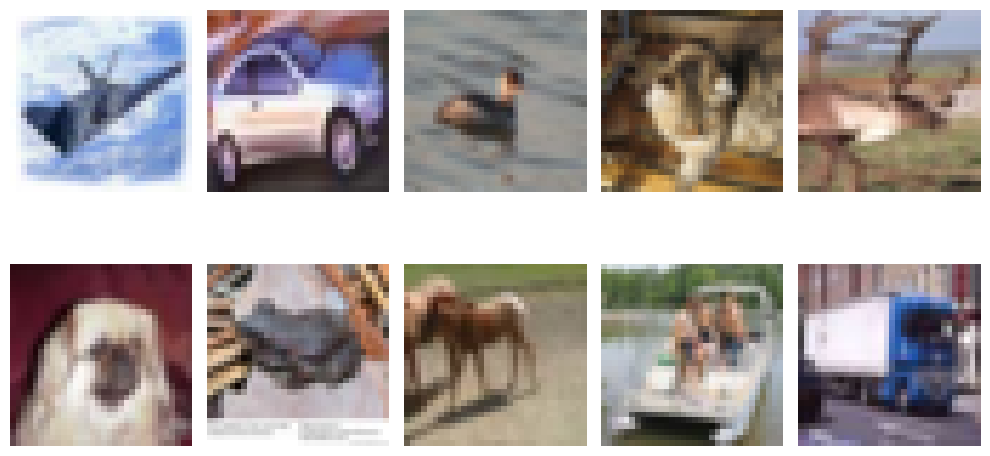

In [279]:
#PLOTANDO 20  figuras aleatórias
plt.figure(figsize=(10,5))

import random
figures = [random.randint(1, 40000) for _ in range(20)]
i = 0
for f in figures:
    plt.subplot(4, 5, i + 1)  
    img = X[f].reshape(3,32,32).transpose(1, 2, 0)
    plt.imshow(img)
    plt.axis('off')            #
    i += 1
plt.tight_layout()
plt.show()

In [280]:
import keras
from keras.datasets import cifar10
from keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from keras.layers import Dense, Activation
import warnings;warnings.filterwarnings(action='ignore')

In [281]:
from sklearn.model_selection import train_test_split
#CONVERTENDO PARA (N, 32, 32, 3) #3 CANAIS
# X = X.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

#SEPARANDO TREINO E TESTE
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X train:", X_train_raw.shape)  
print("X test:", X_test_raw.shape)  
print("y train:", y_train.shape)  
print("y test:", y_test.shape)  

X train: (40000, 3072)
X test: (10000, 3072)
y train: (40000,)
y test: (10000,)


In [ ]:
# PADRONINANDO DE [0,255] PARA [0,1]

X_train = X_train_raw.astype('float32')
X_test = X_test_raw.astype('float32')

mu_train = np.mean(X_train, axis=0)
mu_test = np.mean(X_test, axis=0)
X_train = (X_train - mu_train) / 255.0
X_test  = (X_test  - mu_test) / 255.0


#one hot encoder labels
nlabels = 10
y_train = keras.utils.to_categorical(y_train, nlabels)
y_test  = keras.utils.to_categorical(y_test,  nlabels)


In [ ]:
X_train[0].shape
n_features = 3072
model = Sequential()
model.add(Dense(nlabels), input_shape=(n_features,), activation='softmax')

model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 10)             │        30,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,730 (120.04 KB)

 Trainable params: 30,730 (120.04 KB)

 Non-trainable params: 0 (0.00 B)

In [284]:
model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

In [285]:
ntraing  = 39000
history = model.fit(X_train[:ntraing], y_train[:ntraing],
                    batch_size=512,
                    epochs=15,
                    verbose=2,
                    validation_data=(X_train[ntraing:], y_train[ntraing:]),
                    shuffle=True)

Epoch 1/15
77/77 - 1s - 9ms/step - accuracy: 0.2216 - loss: 2.1355 - val_accuracy: 0.2960 - val_loss: 2.0204
Epoch 2/15
77/77 - 0s - 4ms/step - accuracy: 0.2968 - loss: 1.9965 - val_accuracy: 0.3240 - val_loss: 1.9430
Epoch 3/15
77/77 - 0s - 4ms/step - accuracy: 0.3247 - loss: 1.9421 - val_accuracy: 0.3410 - val_loss: 1.8991
Epoch 4/15
77/77 - 0s - 4ms/step - accuracy: 0.3413 - loss: 1.9092 - val_accuracy: 0.3490 - val_loss: 1.8717
Epoch 5/15
77/77 - 0s - 4ms/step - accuracy: 0.3505 - loss: 1.8860 - val_accuracy: 0.3600 - val_loss: 1.8511
Epoch 6/15
77/77 - 0s - 4ms/step - accuracy: 0.3598 - loss: 1.8685 - val_accuracy: 0.3640 - val_loss: 1.8360
Epoch 7/15
77/77 - 0s - 4ms/step - accuracy: 0.3649 - loss: 1.8545 - val_accuracy: 0.3690 - val_loss: 1.8232
Epoch 8/15
77/77 - 0s - 4ms/step - accuracy: 0.3695 - loss: 1.8430 - val_accuracy: 0.3710 - val_loss: 1.8137
Epoch 9/15
77/77 - 0s - 4ms/step - accuracy: 0.3745 - loss: 1.8334 - val_accuracy: 0.3780 - val_loss: 1.8056
Epoch 10/15
77/77 -

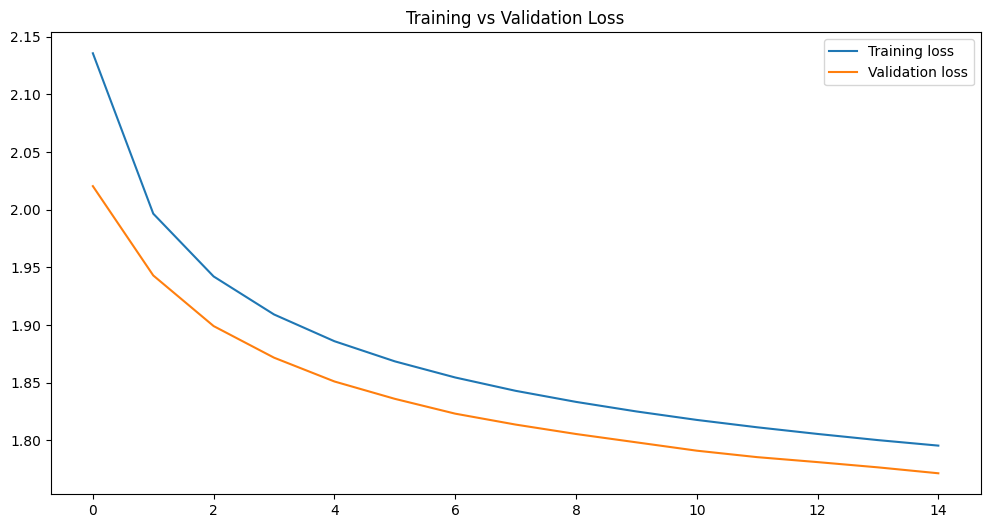

In [287]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label="Training loss")
plt.plot(history.history['val_loss'], label="Validation loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

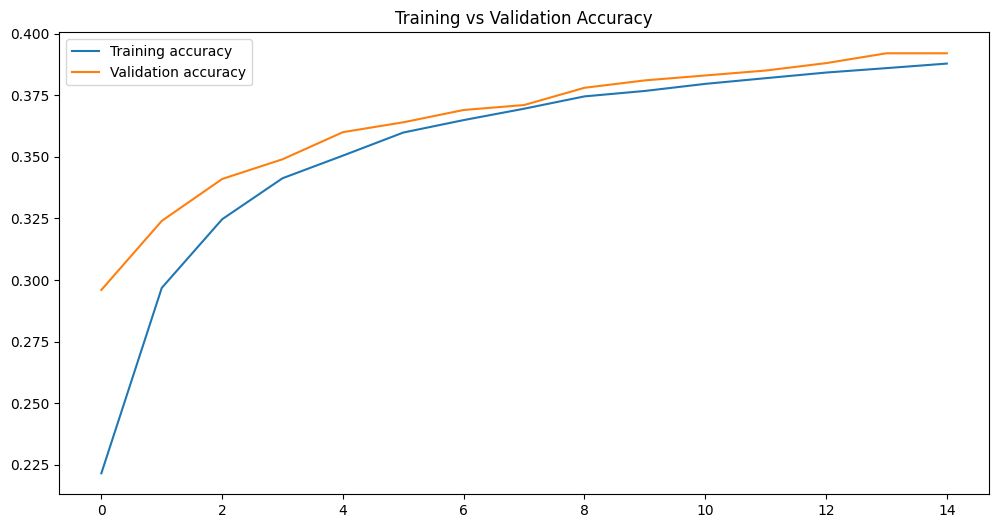

In [288]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label="Training accuracy")
plt.plot(history.history['val_accuracy'], label="Validation accuracy")
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

In [289]:
nimages = 100
idx = np.random.choice(X_test.shape[1], nimages, replace=False)
y_pred = model.predict(X_test[idx]).argmax(axis=1)
y_true = y_test[idx].argmax(axis=1)

print('Test Accuracy = %.2f' % (100.0 * np.mean(y_pred == y_true)))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Test Accuracy = 43.00


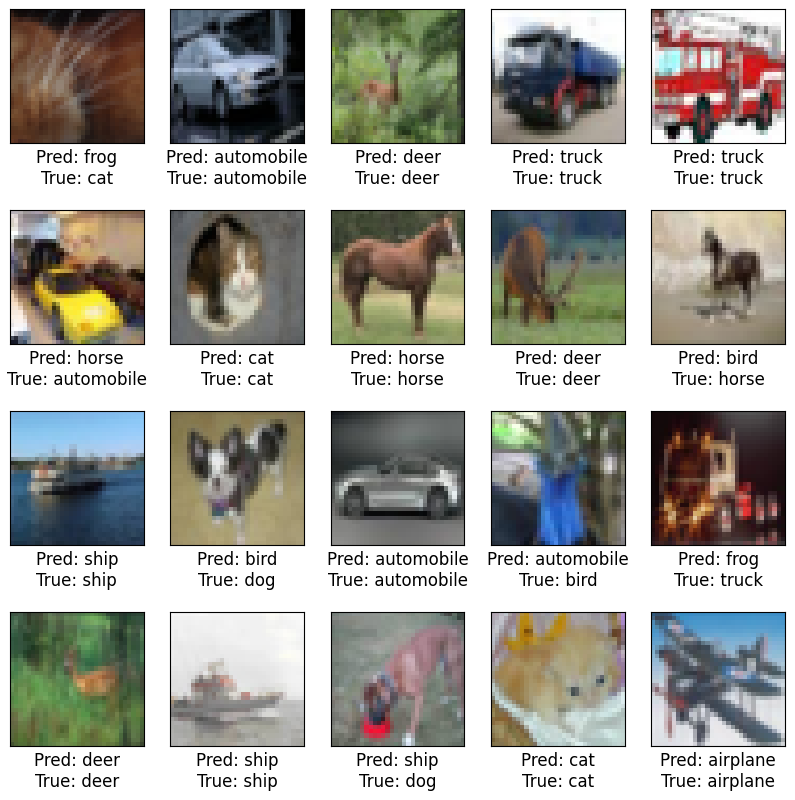

In [ ]:
fig, axes = plt.subplots(4, 5, figsize=(10, 10))
image_size = 32
num_channels = 3
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


for i, ax in enumerate(axes.flat):
    img = X_test_raw[idx[i]].reshape(3, 32, 32).transpose(1, 2, 0)
    ax.imshow(img)
    pred_class = class_names[y_pred[i]]
    true_class = class_names[y_true[i]]
    ax.set_xlabel('Pred: {}\nTrue: {}'.format(pred_class, true_class), fontsize=12)
    ax.set_xticks([])
    ax.set_yticks([])